<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65289 entries, 0 to 65288
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TripID                    65289 non-null  int64  
 1   DepartureLocationCountry  65289 non-null  object 
 2   DepartureLocationCity     65289 non-null  object 
 3   ArrivalLocationCountry    65289 non-null  object 
 4   ArrivalLocationCity       65289 non-null  object 
 5   ShippingType              65289 non-null  int64  
 6   ShippingTypeDescription   65289 non-null  object 
 7   Purpose                   65289 non-null  object 
 8   OutOfPolicy               65289 non-null  object 
 9   EntitiyCode               65289 non-null  int64  
 10  EmployeeNumber            65289 non-null  object 
 11  BusinessUnit              65289 non-null  object 
 12  HotelNights               65289 non-null  int64  
 13  NetCosts                  65289 non-null  int64  
 14  Depart

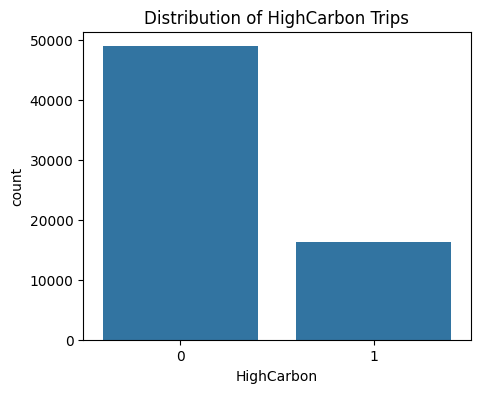

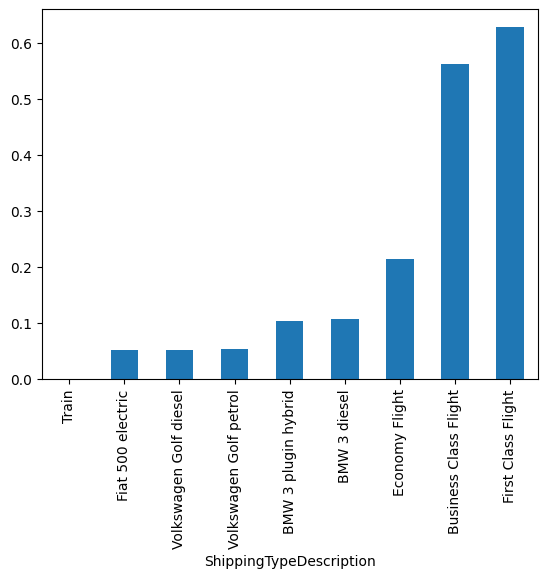

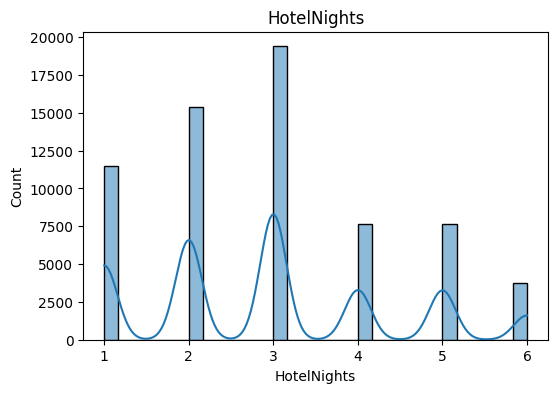

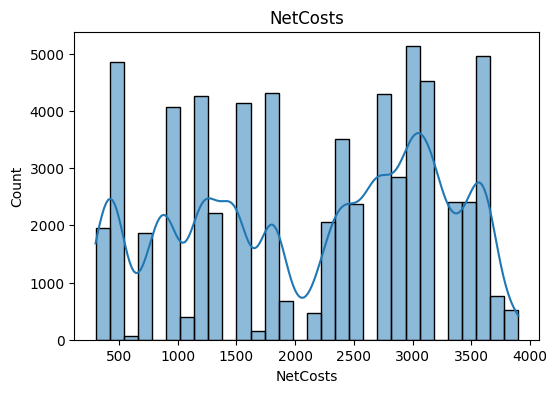

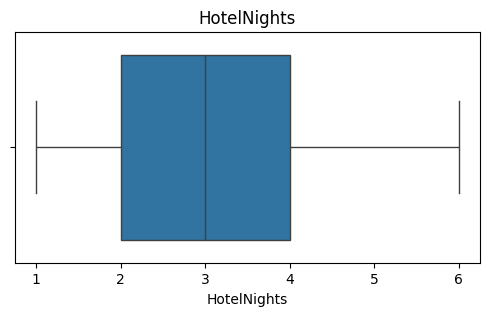

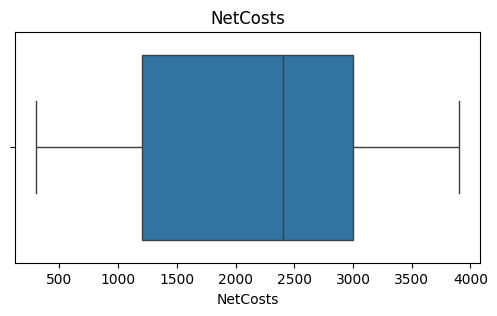

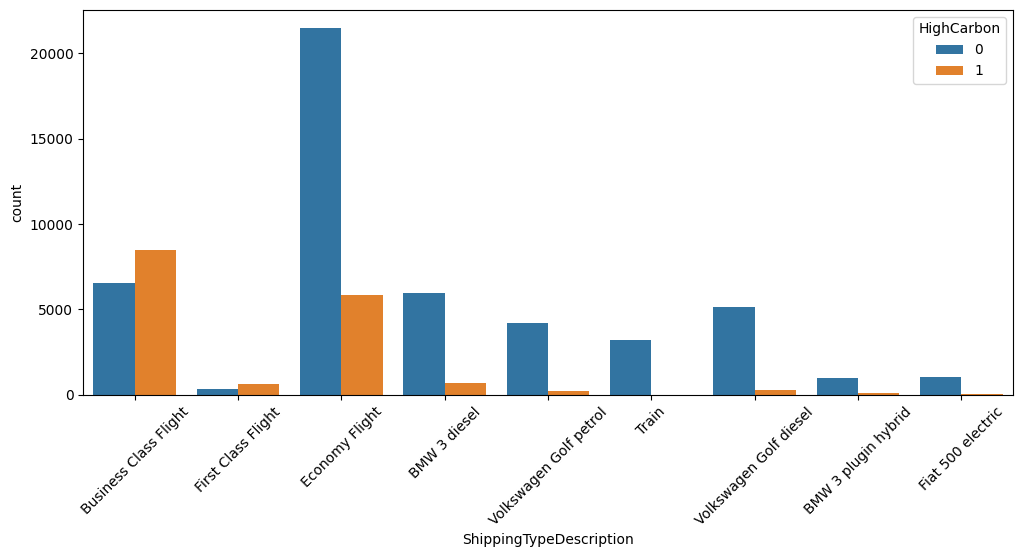

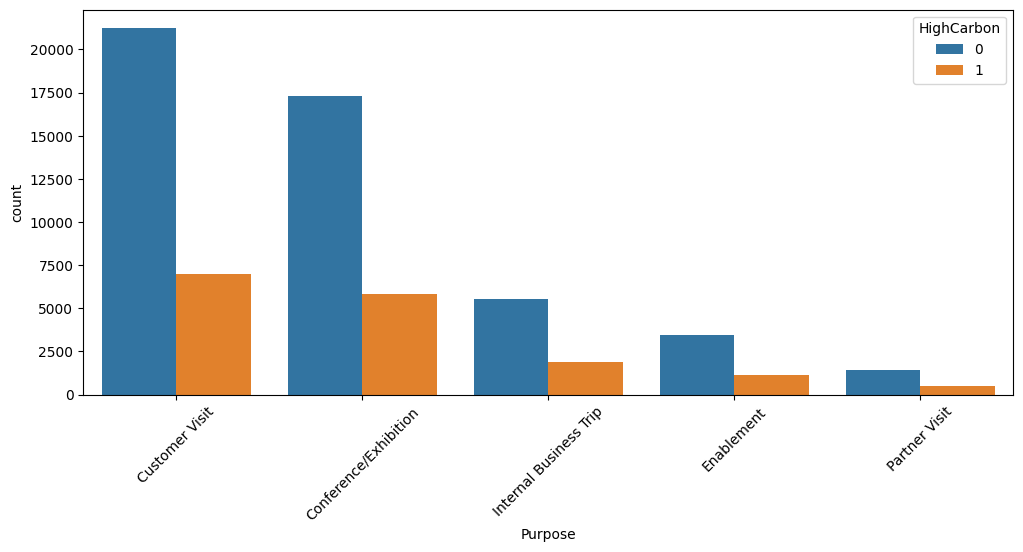

<Axes: xlabel='HighCarbon', ylabel='NetCosts'>

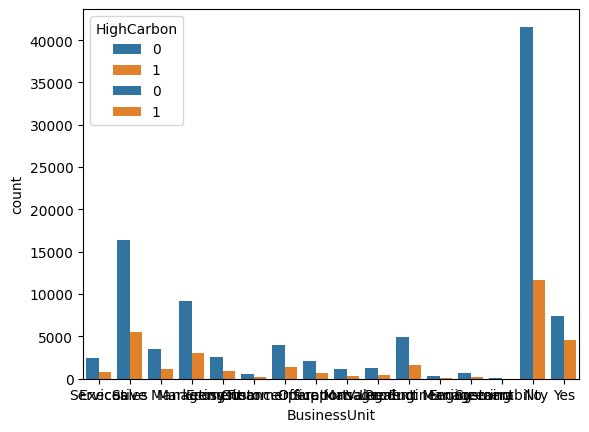

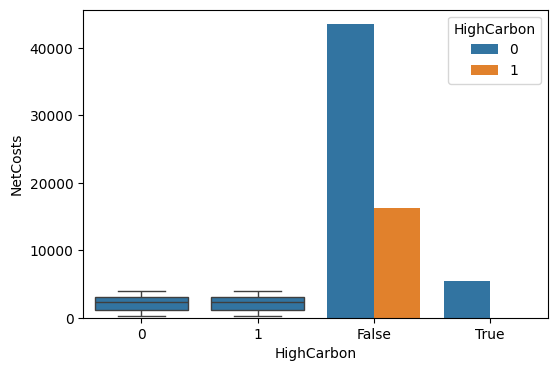

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/public_trip_data.csv")
# print(df)
print(df.info())
# print(df.describe())
# print(df.isnull().sum()) #no nulls

"""
Target
• Departure_CO2e
• Return_CO2e
• Hotel_CO2e
• Spend_CO2e
• TotalCO2e
• HighCarbon
"""

plt.figure(figsize=(5,4))
sns.countplot(data=df, x="HighCarbon")
plt.title("Distribution of HighCarbon Trips")
plt.show()

(df.groupby("ShippingTypeDescription")["HighCarbon"]
   .mean()
   .sort_values()
   .plot(kind="bar"))

num_cols = ["HotelNights","NetCosts"]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)
    plt.show()

for col in ["HotelNights","NetCosts"]:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

plt.figure(figsize=(12,5)) #percent
sns.countplot(data=df,
              x="ShippingTypeDescription",
              hue="HighCarbon")

plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12,5))
sns.countplot(data=df,
              x="Purpose",
              hue="HighCarbon")

plt.xticks(rotation=45)
plt.show()

sns.countplot(data=df,
              x="BusinessUnit",
              hue="HighCarbon")

sns.countplot(data=df,
              x="OutOfPolicy",
              hue="HighCarbon")

plt.figure(figsize=(6,4))
sns.boxplot(data=df,
            x="HighCarbon",
            y="NetCosts")

df["DomesticTrip"] = (
    df["DepartureLocationCountry"] ==
    df["ArrivalLocationCountry"]
)
sns.countplot(
    data=df,
    x="DomesticTrip",
    hue="HighCarbon"
)

In [2]:
# Domestic trip already created

def feature_engineering(data):
    data = data.copy()

    data["CostPerNight"] = (
        data["NetCosts"] / (data["HotelNights"] + 1)
    )

    data["CityPair"] = (
        data["DepartureLocationCity"].astype(str) + "_" +
        data["ArrivalLocationCity"].astype(str)
    )

    data["CountryPair"] = (
        data["DepartureLocationCountry"].astype(str) + "_" +
        data["ArrivalLocationCountry"].astype(str)
    )

    data["DomesticTrip"] = (
        data["DepartureLocationCountry"] ==
        data["ArrivalLocationCountry"]
    ).astype(int)

    data["International"] = (
        data["DepartureLocationCountry"] !=
        data["ArrivalLocationCountry"]
    ).astype(int)

    return data

In [3]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

forbidden = [
    "Departure_CO2e",
    "Return_CO2e",
    "Hotel_CO2e",
    "Spend_CO2e",
    "TotalCO2e",
    "HighCarbon",
    "EmployeeNumber"
]

target = "HighCarbon"

X = df.drop(columns=forbidden)
y = df[target]

cat_cols = X.select_dtypes(include="object").columns

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
], remainder="passthrough")

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

pipe = Pipeline([
    ("prep", preprocessor),
    ("model", model)
])

pipe.fit(X_train, y_train)

pred = pipe.predict_proba(X_val)[:, 1]

auc = roc_auc_score(y_val, pred)

print("ROC-AUC:", auc)

ROC-AUC: 0.9998486120582739


In [4]:
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

pred_prob = pipe.predict_proba(X_val)[:, 1]
pred_class = (pred_prob >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_val, pred_prob))
print("Precision:", precision_score(y_val, pred_class))
print("Recall:", recall_score(y_val, pred_class))
print("F1 Score:", f1_score(y_val, pred_class))

print("Confusion Matrix:")
print(confusion_matrix(y_val, pred_class))

ROC-AUC: 0.9998486120582739
Precision: 0.9898399014778325
Recall: 0.9846860643185299
F1 Score: 0.9872562567173345
Confusion Matrix:
[[9760   33]
 [  50 3215]]


In [5]:
feature_names = pipe.named_steps["prep"].get_feature_names_out()
importances = pipe.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(importance_df.head(15))

                                              Feature  Importance
45                 cat__ArrivalLocationCity_Frankfurt    0.270204
67  cat__ShippingTypeDescription_Business Class Fl...    0.135161
7                    cat__DepartureLocationCountry_US    0.057348
50               cat__ArrivalLocationCity_Los Angeles    0.039600
3                    cat__DepartureLocationCountry_DE    0.035546
25                     cat__ArrivalLocationCountry_FR    0.035344
23                     cat__ArrivalLocationCountry_DE    0.029477
2                    cat__DepartureLocationCountry_CN    0.029329
29                     cat__ArrivalLocationCountry_JP    0.028379
27                     cat__ArrivalLocationCountry_IN    0.026779
21                     cat__ArrivalLocationCountry_CA    0.022757
1                    cat__DepartureLocationCountry_BR    0.022118
30                     cat__ArrivalLocationCountry_MX    0.021335
70    cat__ShippingTypeDescription_First Class Flight    0.020110
19        

In [6]:
private = pd.read_csv("../data/private_trip_data.csv")

private = feature_engineering(private)

preds = pipe.predict_proba(private)[:, 1]

print(preds[:10])
print("Number of predictions:", len(preds))

[9.9541807e-01 1.8290902e-03 9.4479561e-01 9.6487429e-04 8.1251800e-04
 3.0407147e-03 9.8806924e-01 9.7674632e-01 3.6134556e-05 6.6392538e-03]
Number of predictions: 21764


In [7]:
submission = pd.DataFrame({
    "TripID": private["TripID"],
    "HighCarbon": preds
})

submission.to_csv("../results/submission.csv", index=False)

print(submission.head())
print(submission.shape)

   TripID  HighCarbon
0       2    0.995418
1       4    0.001829
2       5    0.944796
3      14    0.000965
4      15    0.000813
(21764, 2)
